# Audio Signal Processing Lab
Variants **2** and **8**

Tasks:
- Generate noise (pink for even variants)
- Apply required filters
- Show frequency response (FFT / "АЧХ") and spectrograms
- Process external audio fragments (speech, music, sample)

Expected audio files for part 2 in the same folder:
- `speech.wav`
- `music.wav`
- `sample.wav`


In [1]:
import numpy as np
import scipy.signal as signal
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt
import librosa

import subprocess
from pathlib import Path

plt.rcParams['figure.figsize'] = (10,4)

## Helper functions

In [2]:
def pink_noise(n):
    white = np.random.randn(n)
    b = [0.049922035, -0.095993537, 0.050612699, -0.004408786]
    a = [1, -2.494956002, 2.017265875, -0.522189400]
    return signal.lfilter(b, a, white)


IMG_DIR = Path("./img")
IMG_DIR.mkdir(parents=True, exist_ok=True)


def make_img_path(file_name):
    return IMG_DIR / file_name


def show_fft(sig, fs, title="FFT", save_path=None):
    f = np.fft.rfftfreq(len(sig), 1/fs)
    spec = np.abs(np.fft.rfft(sig))
    plt.figure(figsize=(10, 4))
    plt.plot(f, spec)
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def show_spectrogram(sig, fs, title="Spectrogram", max_freq=None, save_path=None):
    sig = np.asarray(sig, dtype=np.float32)

    f, t, S = signal.spectrogram(
        sig,
        fs=fs,
        window="hann",
        nperseg=1024,
        noverlap=768
    )

    S_db = 10 * np.log10(S + 1e-10)

    if max_freq is None:
        max_freq = fs / 2

    mask = f <= max_freq

    plt.figure(figsize=(10, 4))
    plt.pcolormesh(t, f[mask], S_db[mask], shading="gouraud", cmap="magma")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(title)
    plt.colorbar(label="Power (dB)")
    plt.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def to_float_mono(data):
    data = np.asarray(data)
    if data.ndim > 1:
        data = data.mean(axis=1)

    data = data.astype(np.float32)
    max_val = np.max(np.abs(data))
    if max_val > 0:
        data = data / max_val
    return data


def calc_rms_metrics(y):
    rms = librosa.feature.rms(y=y, frame_length=2048, hop_length=512)[0]
    return {
        "rms_mean": float(np.mean(rms)),
        "rms_std": float(np.std(rms)),
        "rms_max": float(np.max(rms)),
    }


def calc_voice_metrics(y, sr):
    zcr = librosa.feature.zero_crossing_rate(
        y, frame_length=2048, hop_length=512
    )[0]
    f0 = librosa.yin(
        y,
        fmin=librosa.note_to_hz("C2"),
        fmax=librosa.note_to_hz("C7"),
        sr=sr
    )
    f0_valid = f0[np.isfinite(f0)]

    pitch_mean = float(np.mean(f0_valid)) if f0_valid.size else float("nan")
    pitch_median = float(np.median(f0_valid)) if f0_valid.size else float("nan")

    return {
        "zcr_mean": float(np.mean(zcr)),
        "zcr_std": float(np.std(zcr)),
        "pitch_mean_hz": pitch_mean,
        "pitch_median_hz": pitch_median,
    }


def calc_music_metrics(y, sr):
    chroma = librosa.feature.chroma_stft(
        y=y, sr=sr, n_fft=2048, hop_length=512
    )
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    tempo_bpm = float(np.ravel(np.asarray(tempo))[0])

    chroma_mean = chroma.mean(axis=1)
    chroma_labels = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
    dominant_chroma = chroma_labels[int(np.argmax(chroma_mean))]

    return {
        "tempo_bpm": tempo_bpm,
        "dominant_chroma": dominant_chroma,
    }


def mp4_to_wav(input_file, output_file=None, sample_rate=44100):

    input_path = Path(input_file)

    if not input_path.exists():
        raise FileNotFoundError(f"Input file not found: {input_file}")

    if output_file is None:
        output_file = input_path.with_suffix(".wav")

    command = [
        "ffmpeg",
        "-y",                    # overwrite output
        "-i", str(input_file),
        "-vn",                   # ignore video
        "-ac", "1",              # mono
        "-ar", str(sample_rate), # sample rate
        str(output_file)
    ]

    try:
        subprocess.run(
            command,
            check=True,
            capture_output=True,
            text=True
        )
        return output_file

    except subprocess.CalledProcessError as e:
        print("FFmpeg error:")
        print(e.stderr)
        raise


def download_mp3_to_wav(url, output_wav=None, sample_rate=44100, temp_mp3=None, keep_mp3=False, timeout=60):
    import requests
    from urllib.parse import unquote, urlparse

    parsed = urlparse(url)
    if parsed.scheme not in ("http", "https"):
        raise ValueError("URL must start with http:// or https://")

    if output_wav is None:
        name = Path(unquote(parsed.path)).stem or "downloaded_audio"
        output_wav = Path(f"{name}.wav")
    else:
        output_wav = Path(output_wav)

    if temp_mp3 is None:
        temp_mp3 = output_wav.with_suffix(".mp3")
    else:
        temp_mp3 = Path(temp_mp3)

    output_wav.parent.mkdir(parents=True, exist_ok=True)
    temp_mp3.parent.mkdir(parents=True, exist_ok=True)

    with requests.get(url, stream=True, timeout=timeout) as response:
        response.raise_for_status()
        with open(temp_mp3, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

    command = [
        "ffmpeg",
        "-y",
        "-i", str(temp_mp3),
        "-vn",
        "-ac", "1",
        "-ar", str(sample_rate),
        str(output_wav),
    ]

    try:
        subprocess.run(command, check=True, capture_output=True, text=True)
    except subprocess.CalledProcessError as e:
        print("FFmpeg error:")
        print(e.stderr)
        raise
    finally:
        if not keep_mp3 and temp_mp3.exists():
            temp_mp3.unlink()

    return output_wav

In [3]:
wav_path = mp4_to_wav("../monologue.MP4")
# wav_path = download_mp3_to_wav(
#     "https://lambda.vgmtreasurechest.com/soundtracks/minecraft/bgdvvqqi/1-18.%20Sweden.mp3",
#     output_wav="../audio/from_url.wav",
#     sample_rate=44100
# )
# print(wav_path)

# PART 1 — Noise

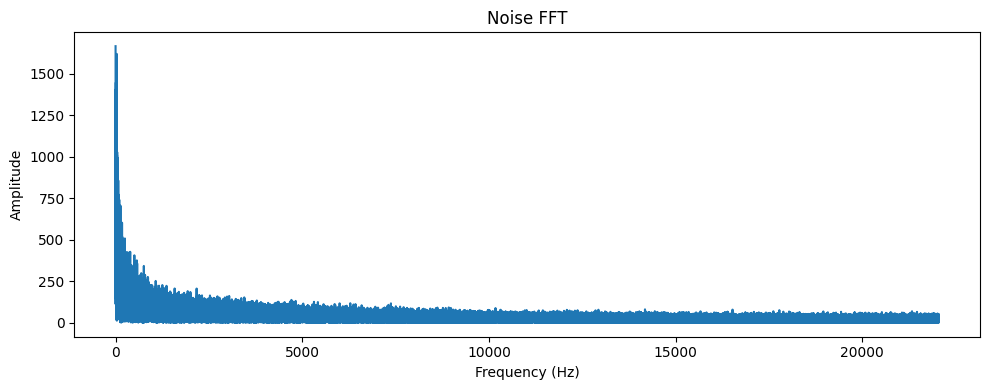

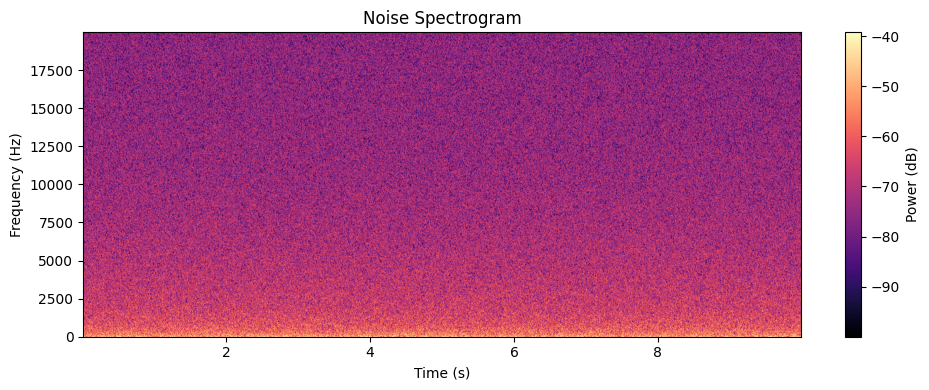

In [4]:
fs = 44100
duration = 10
N = fs * duration

# even variants -> pink noise
noise = pink_noise(N)

show_fft(noise, fs, "Noise FFT", save_path=make_img_path("fft_noise.png"))
show_spectrogram(
    noise,
    fs,
    "Noise Spectrogram",
    max_freq=20000,
    save_path=make_img_path("spectrogram_noise.png")
)

# Variant 2 filters
X = 2 → low‑pass
Y = 10 → FIR

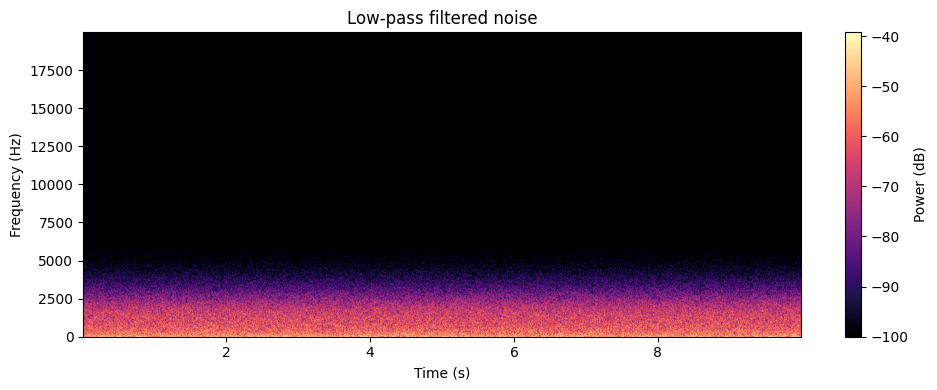

In [5]:
# Low-pass filter
b_lp, a_lp = signal.butter(4, 2000/(fs/2), btype='low')
noise_lp = signal.lfilter(b_lp, a_lp, noise)

show_spectrogram(
    noise_lp,
    fs,
    "Low-pass filtered noise",
    max_freq=20000,
    save_path=make_img_path("spectrogram_noise_lowpass.png")
)

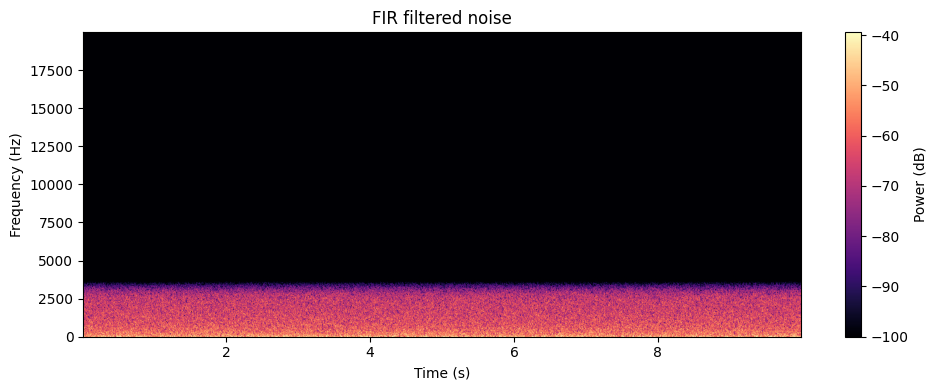

In [6]:
# FIR filter
fir = signal.firwin(101, cutoff=3000, fs=fs)
noise_fir = signal.lfilter(fir, [1], noise)

show_spectrogram(
    noise_fir,
    fs,
    "FIR filtered noise",
    max_freq=20000,
    save_path=make_img_path("spectrogram_noise_fir.png")
)

# PART 2 — Real audio

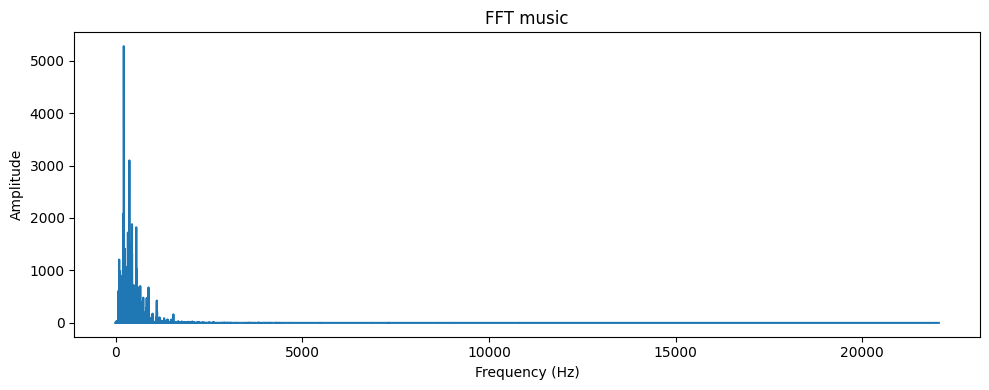

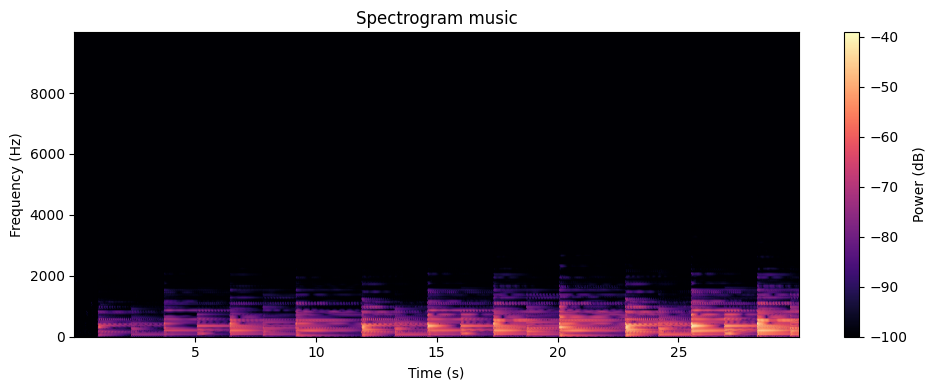

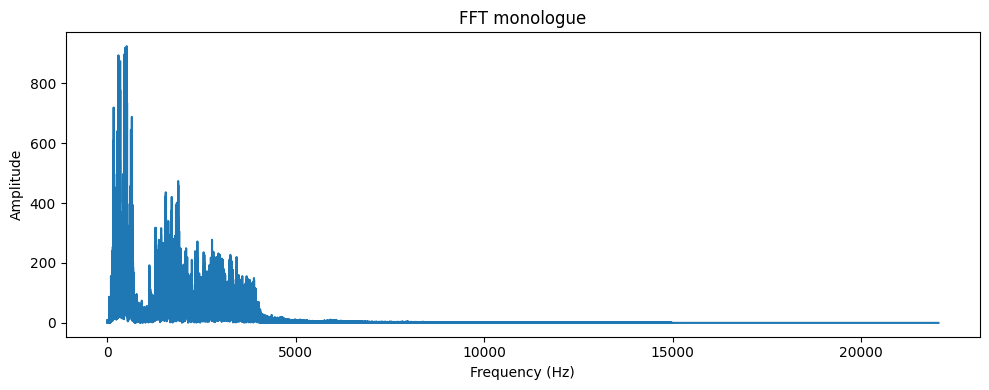

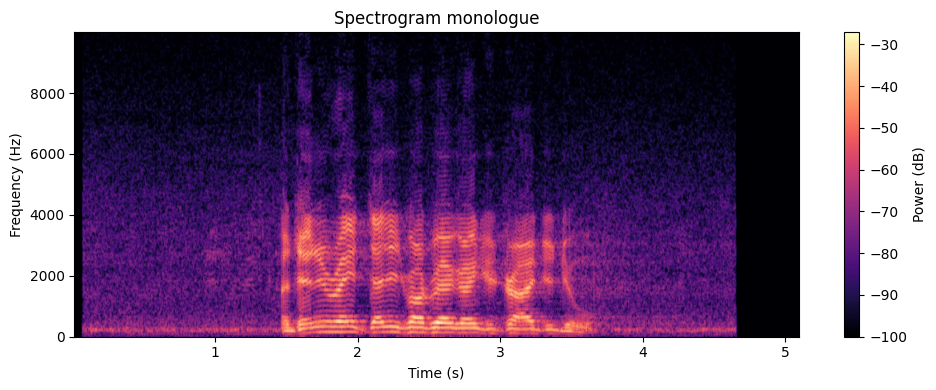

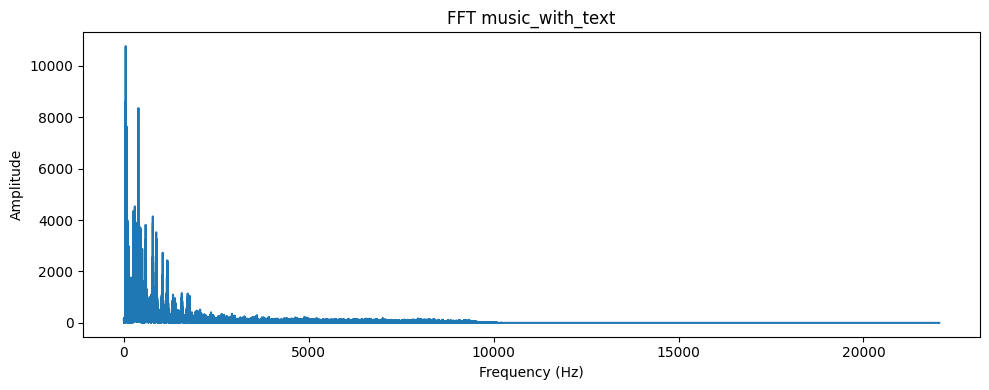

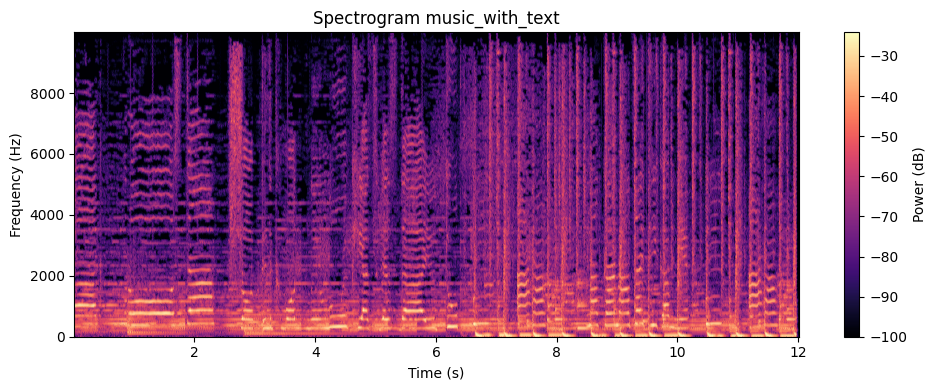


[music] type=music
RMS mean=0.016190, std=0.015674, max=0.106768
Music metrics: dominant chroma=A, tempo=21.99 BPM

[monologue] type=voice
RMS mean=0.078814, std=0.093076, max=0.368816
Voice metrics: ZCR mean=0.051642, std=0.023110, pitch mean=370.54 Hz, pitch median=210.53 Hz

[music_with_text] type=mixed
RMS mean=0.251664, std=0.106375, max=0.520248
Voice metrics: ZCR mean=0.039064, std=0.027792, pitch mean=228.28 Hz, pitch median=147.55 Hz
Music metrics: dominant chroma=D, tempo=126.05 BPM


In [7]:
audio_items = [
    {"label": "music", "path": "../audio/music.wav", "kind": "music"},
    {"label": "monologue", "path": "../audio/monologue.wav", "kind": "voice"},
    {"label": "music_with_text", "path": "../audio/music_with_text.wav", "kind": "mixed"},
]

metrics_rows = []

for item in audio_items:
    fs, data = wav.read(item["path"])
    y = to_float_mono(data)

    max_samples = int(30 * fs)
    y = y[:max_samples]

    show_fft(
        y,
        fs,
        f"FFT {item['label']}",
        save_path=make_img_path(f"fft_{item['label']}.png")
    )
    show_spectrogram(
        y,
        fs,
        f"Spectrogram {item['label']}",
        max_freq=10000,
        save_path=make_img_path(f"spectrogram_{item['label']}.png")
    )

    row = {
        "file": item["label"],
        "type": item["kind"],
    }
    row.update(calc_rms_metrics(y))

    if item["kind"] in ("voice", "mixed"):
        row.update(calc_voice_metrics(y, fs))

    if item["kind"] in ("music", "mixed"):
        row.update(calc_music_metrics(y, fs))

    metrics_rows.append(row)

for row in metrics_rows:
    print()
    print(f"[{row['file']}] type={row['type']}")
    print(f"RMS mean={row['rms_mean']:.6f}, std={row['rms_std']:.6f}, max={row['rms_max']:.6f}")

    if "zcr_mean" in row:
        print(
            f"Voice metrics: ZCR mean={row['zcr_mean']:.6f}, "
            f"std={row['zcr_std']:.6f}, pitch mean={row['pitch_mean_hz']:.2f} Hz, "
            f"pitch median={row['pitch_median_hz']:.2f} Hz"
        )

    if "tempo_bpm" in row:
        print(
            f"Music metrics: dominant chroma={row['dominant_chroma']}, "
            f"tempo={row['tempo_bpm']:.2f} BPM"
        )

## Apply filters

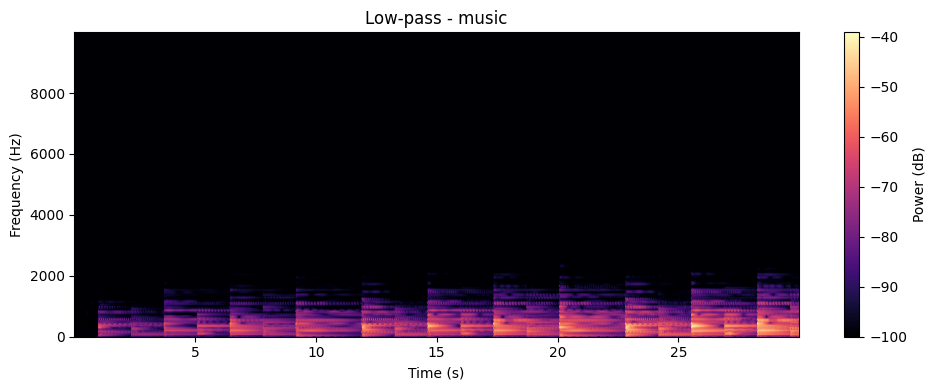

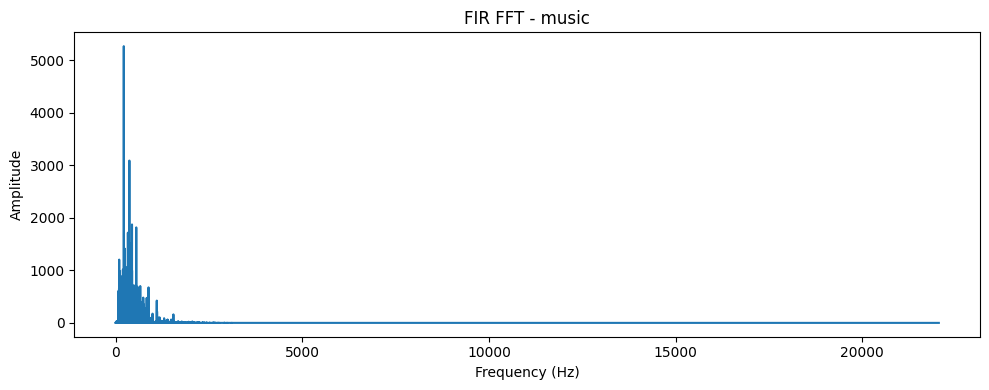

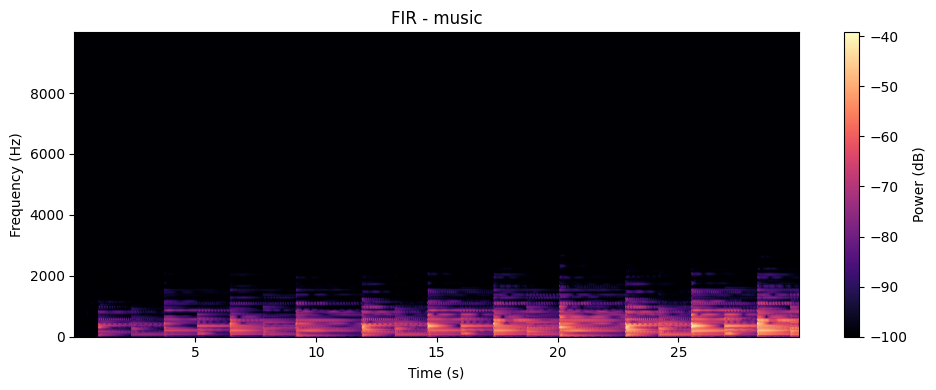

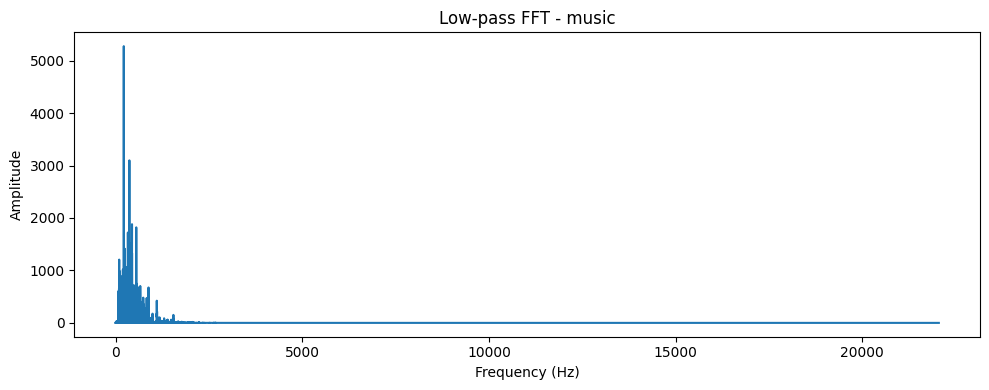

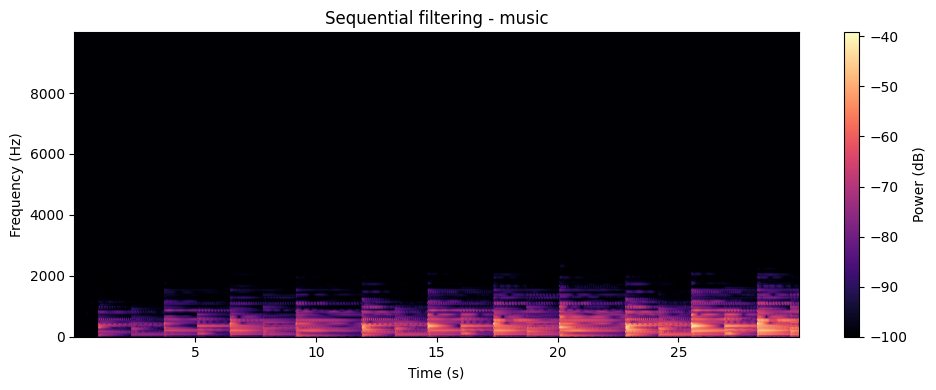

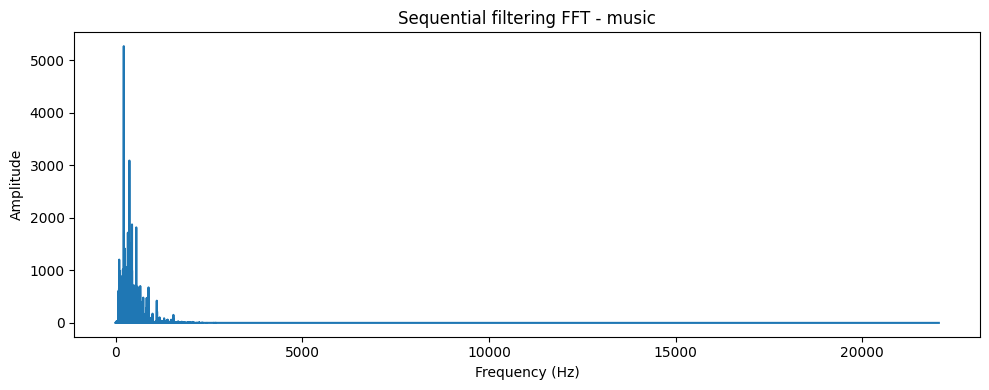

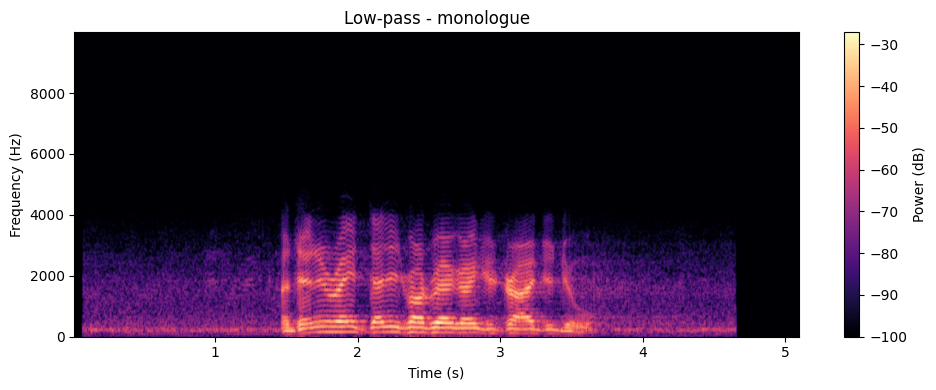

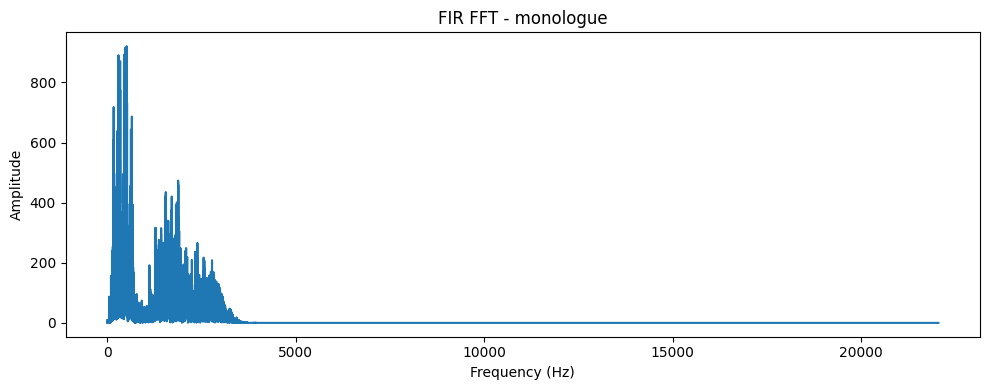

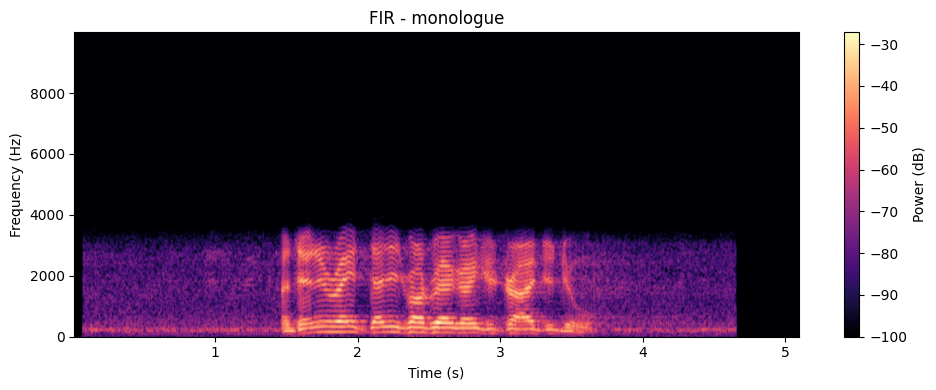

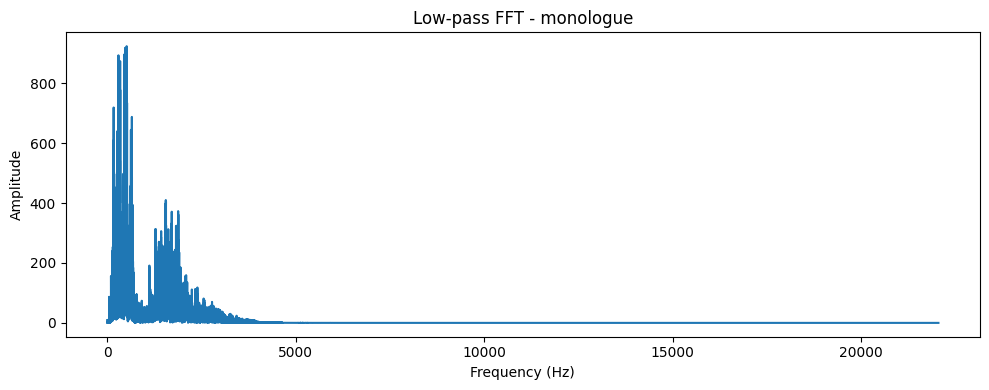

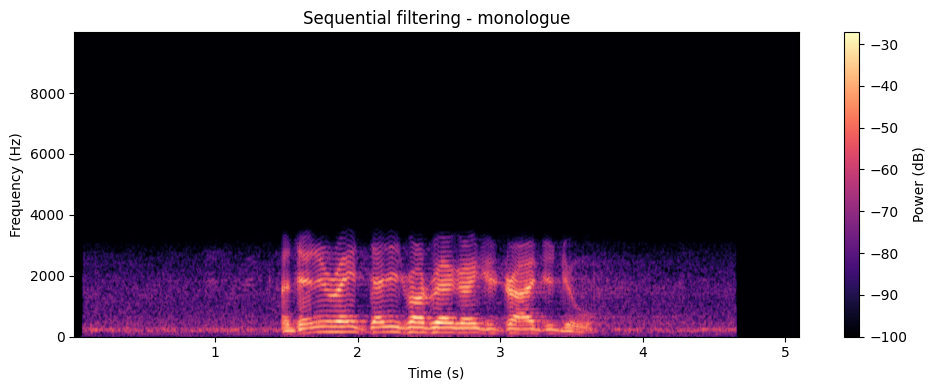

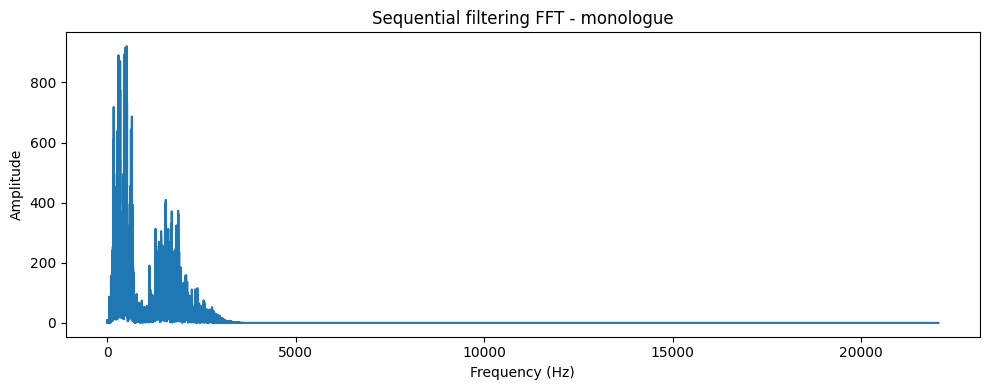

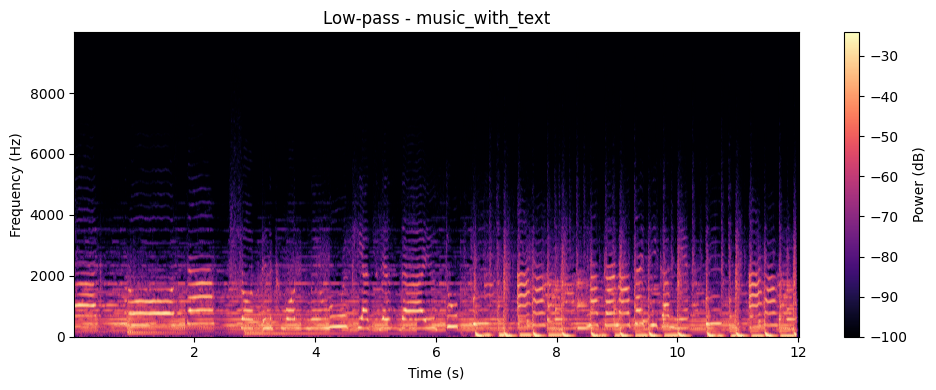

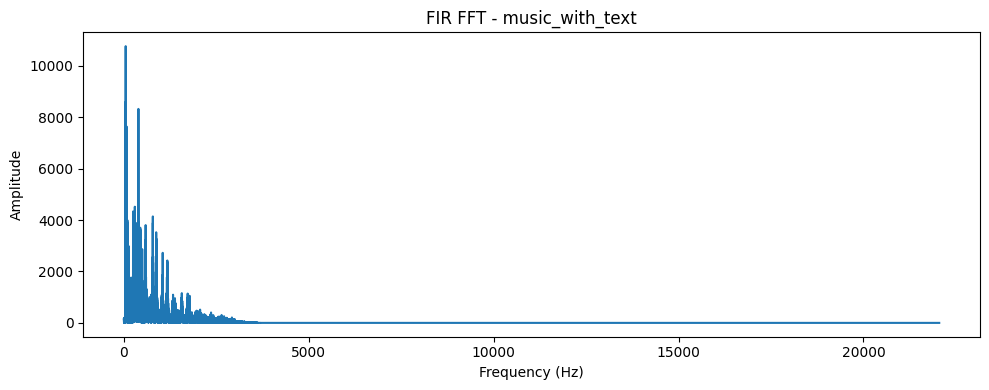

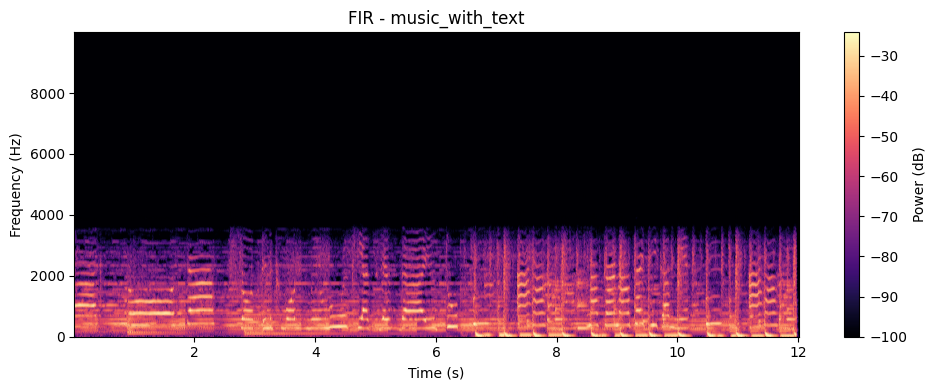

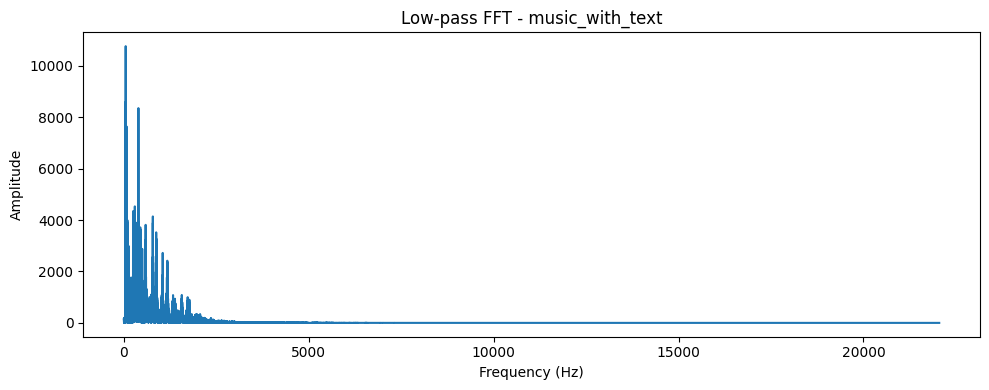

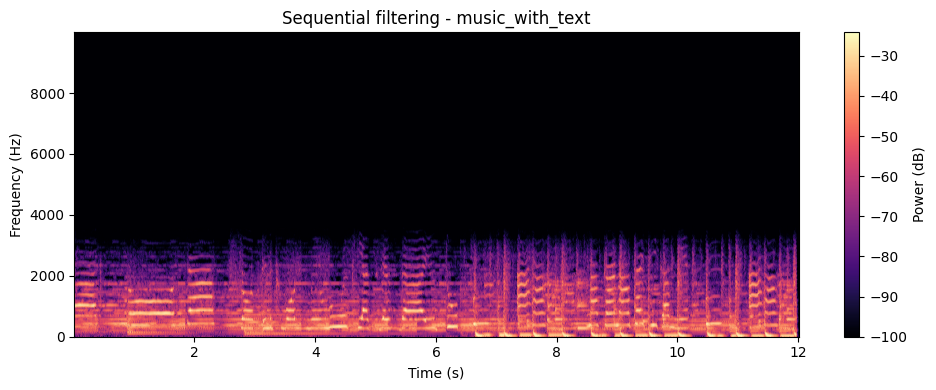

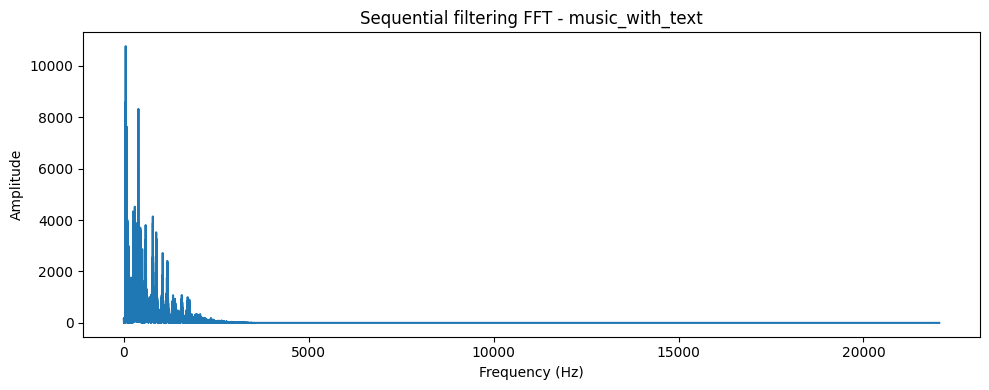

In [12]:
def process_audio(data, fs, label="Audio"):
    y = to_float_mono(data)
    y = y[:int(30 * fs)]
    lp = signal.lfilter(b_lp, a_lp, y)
    firf = signal.lfilter(fir, [1], y)

    show_spectrogram(
        lp,
        fs,
        f"Low-pass - {label}",
        max_freq=10000,
        save_path=make_img_path(f"spectrogram_lowpass_{label}.png")
    )

    show_fft(
        firf,
        fs,
        f"FIR FFT - {label}",
        save_path=make_img_path(f"fft_fir_{label}.png")
    )
    show_spectrogram(
        firf,
        fs,
        f"FIR - {label}",
        max_freq=10000,
        save_path=make_img_path(f"spectrogram_fir_{label}.png")
    )
    show_fft(
        lp,
        fs,
        f"Low-pass FFT - {label}",
        save_path=make_img_path(f"fft_lowpass_{label}.png")
    )

    seq = signal.lfilter(fir, [1], signal.lfilter(b_lp, a_lp, y))
    show_spectrogram(
        seq,
        fs,
        f"Sequential filtering - {label}",
        max_freq=10000,
        save_path=make_img_path(f"spectrogram_sequential_{label}.png")
    )
    show_fft(
        seq,
        fs,
        f"Sequential filtering FFT - {label}",
        save_path=make_img_path(f"fft_sequential_{label}.png")
    )

for item in audio_items:
    fs, data = wav.read(item["path"])

    process_audio(data, fs, label=item["label"])

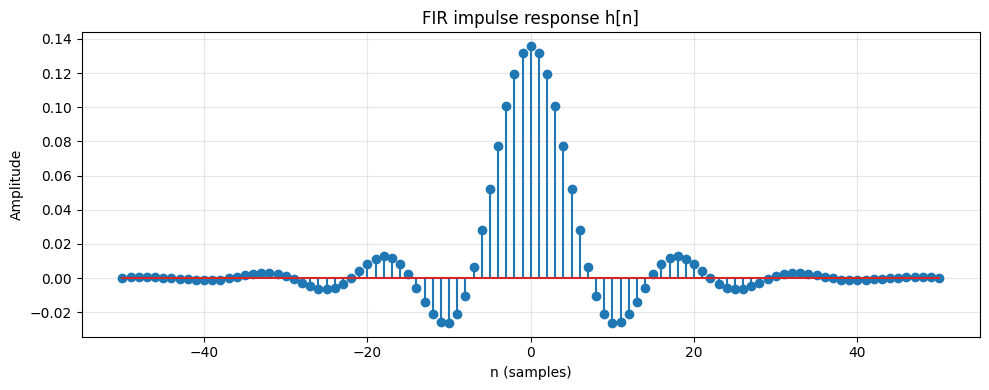

In [9]:
h_fir = fir
n = np.arange(len(h_fir)) - (len(h_fir)-1)/2

plt.figure(figsize=(10,4))
plt.stem(n, h_fir)

plt.title("FIR impulse response h[n]")
plt.xlabel("n (samples)")
plt.ylabel("Amplitude")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

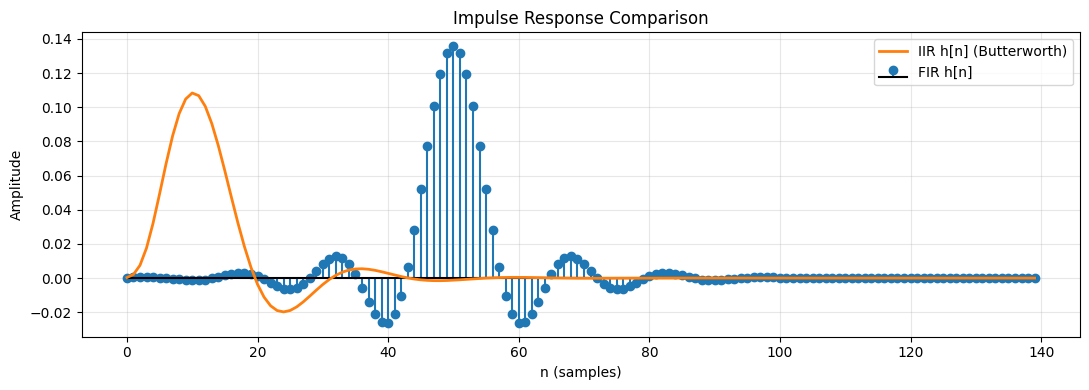

In [10]:
# Compare impulse responses: FIR vs IIR

N = 512

# единичный импульс δ[n]
delta = np.zeros(N, dtype=np.float32)
delta[0] = 1.0

# импульсные отклики
h_fir_full = signal.lfilter(fir, [1], delta)
h_iir_full = signal.lfilter(b_lp, a_lp, delta)

# сколько отсчётов показать
show_n = 140
n = np.arange(show_n)

plt.figure(figsize=(11, 4))

# FIR
plt.stem(
    n,
    h_fir_full[:show_n],
    linefmt='C0-',
    markerfmt='C0o',
    basefmt='k-',
    label='FIR h[n]'
)

# IIR
plt.plot(
    n,
    h_iir_full[:show_n],
    'C1',
    lw=2,
    label='IIR h[n] (Butterworth)'
)

plt.title("Impulse Response Comparison")
plt.xlabel("n (samples)")
plt.ylabel("Amplitude")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

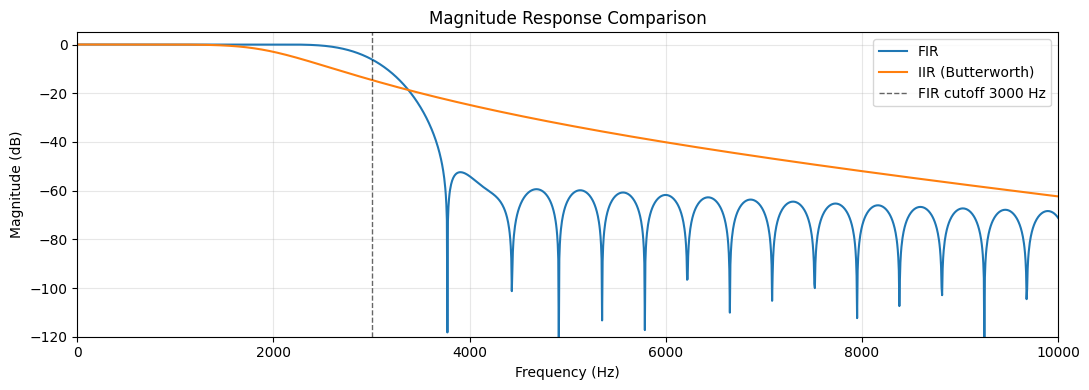

In [11]:
# Compare magnitude response (frequency response)

w_fir, H_fir = signal.freqz(
    fir,
    [1],
    worN=4096,
    fs=fs
)

w_iir, H_iir = signal.freqz(
    b_lp,
    a_lp,
    worN=4096,
    fs=fs
)

eps = 1e-12

mag_fir_db = 20 * np.log10(np.abs(H_fir) + eps)
mag_iir_db = 20 * np.log10(np.abs(H_iir) + eps)

plt.figure(figsize=(11, 4))

plt.plot(w_fir, mag_fir_db, label="FIR")
plt.plot(w_iir, mag_iir_db, label="IIR (Butterworth)")

plt.axvline(
    3000,
    color="k",
    ls="--",
    lw=1,
    alpha=0.6,
    label="FIR cutoff 3000 Hz"
)

plt.xlim(0, 10000)
plt.ylim(-120, 5)

plt.title("Magnitude Response Comparison")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()